# Preprocess MVP — Stage Walkthrough (Presentable Findings)

**Audience:** stakeholder / demo walkthrough of the tender-offer preprocess path.

**Product question this answers:** Can we turn public SEC tender filings into a **citable Concise Representation** that an agent can use for BNY-shaped notification fields — without inventing BNY-internal data?

```text
inventory → download → cleanup → segment → GLiNER → assemble → (load_db)
```

| What we measured (gold cohort on disk) | Result |
|---|---|
| Gold events with Concise Rep | **29 / 29** |
| Raw priority docs downloaded | **~109** (cover + OTP ± LoT + 14D-9) |
| Upstream quality gates pass | **~26 / 29** (price/date/offeror/passage checks) |
| Top-1 `offer_price` is `$…` shaped | **29 / 29** |
| Extraction method | **100% GLiNER** (no regex field discovery) |

Docs: [`lld-preprocess-pipeline.md`](../docs/lld-preprocess-pipeline.md) · [`schema.md`](../docs/schema.md) · [`preprocess-stage-io-example.md`](../docs/preprocess-stage-io-example.md)


In [1]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

from src.preprocess.quality_gates import check_event_rep, check_gold_artifacts
from src.preprocess.store import DEFAULT_PREPROCESS_ROOT, ArtifactStore
from src.preprocess.metrics import collect_stage_metrics, write_metrics_csv
from src.preprocess.viz import (
    plot_cohort_mix,
    plot_pipeline_funnel,
    plot_quality_gates,
    plot_top1_field_readiness,
    run_viz,
)

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_rows", 80)

PATH_NAME = "tender"
STORE = ArtifactStore(PATH_NAME, DEFAULT_PREPROCESS_ROOT)
EVENTS_ROOT = STORE.path_root / "events"
EVENT_IDS = sorted(p.name for p in EVENTS_ROOT.iterdir() if p.is_dir() and (p / "inventory.json").exists())
print(f"preprocess root: {STORE.path_root}")
print(f"events on disk: {len(EVENT_IDS)}")


preprocess root: /Users/kedarvaidya/Desktop/BNY-Capstone-Project/data/preprocess/tender
events on disk: 30


## Why a staged pipeline?

| Stage | Why it exists | What would break without it |
|---|---|---|
| **Inventory** | Pick the *right* filings (cover / OTP / LoT / 14D-9) from EDGAR metadata — not every exhibit | Agent reads junk PDFs, fee tables, signatures |
| **Download** | Persist raw HTML bytes with provenance (accession, sha1) | No reproducible citations |
| **Cleanup** | Strip EDGAR wrappers + HTML → readable text | GLiNER sees tags/noise, offsets meaningless |
| **Segment** | Cut OTP into Summary Term Sheet / FAQ / TOC sections | Model truncates 50+ page OTP; misses price FAQ |
| **GLiNER** | Zero-shot span extraction (values, not headings) | No candidate facts for the agent |
| **Assemble** | Pack Concise Rep: ranked facts + passages + doc inventory | Downstream has no single event JSON |
| **load_db** | Path-isolated Postgres for multi-path MVP | Can't join events for app / eval |

**Hard rule:** stages may **rank/filter** GLiNER spans; they must **not** regex-search filings to invent new field values.


## 0. Cohort snapshot — what we can present today


In [2]:
rows = []
for eid in EVENT_IDS:
    inv = STORE.read_json(STORE.inventory_path(eid))
    seg = STORE.read_json(STORE.segments_path(eid)) if STORE.segments_path(eid).exists() else {}
    spans = STORE.read_json(STORE.spans_path(eid)) if STORE.spans_path(eid).exists() else {}
    rep_path = STORE.event_rep_path(eid)
    rep = STORE.read_json(rep_path) if rep_path.exists() else {}
    facts = rep.get("candidate_facts") or []
    gate = check_event_rep(rep) if facts else {"ok": False, "failures": ["missing_rep"], "checks": {}}
    kinds = Counter(s.get("kind") for s in (seg.get("segments") or []))
    rows.append({
        "event_id": eid,
        "entity": inv.get("primary_entity"),
        "cohort": inv.get("cohort"),
        "n_docs": len(inv.get("docs") or []),
        "has_otp": inv.get("has_otp"),
        "has_14d9": inv.get("has_14d9"),
        "n_segments": seg.get("n_segments"),
        "n_faq": kinds.get("faq", 0),
        "n_priority": kinds.get("priority_section", 0),
        "n_spans": spans.get("n_spans"),
        "n_facts": len(facts),
        "top_offer_price": gate["checks"].get("top1_offer_price"),
        "top_expiration": gate["checks"].get("top1_expiration_date"),
        "top_offeror": gate["checks"].get("top1_offeror"),
        "gate_ok": gate["ok"],
        "gate_failures": ", ".join(gate.get("failures") or []),
        "passage_p50": gate["checks"].get("passage_len_median"),
    })

cohort = pd.DataFrame(rows).sort_values("event_id")
display(Markdown(
    f"### Gold / inventoried events: **{len(cohort)}** · "
    f"Concise Reps: **{(cohort['n_facts']>0).sum()}** · Gates pass: **{cohort['gate_ok'].sum()}**"
))
display(cohort[[
    "event_id", "entity", "cohort", "n_docs", "n_segments", "n_faq", "n_spans",
    "top_offer_price", "top_expiration", "top_offeror", "gate_ok"
]].head(12))


### Gold / inventoried events: **30** · Concise Reps: **29** · Gates pass: **26**

,event_id,entity,cohort,n_docs,n_segments,n_faq,n_spans,top_offer_price,top_expiration,top_offeror,gate_ok
0,005-02933,"VOLT INFORMATION SCIENCES, INC.",gold,4,22.0,0,69.0,$6.00,"March 12, 2022","AmericanCyberSystems, Inc.",True
1,005-06295,VECTOR GROUP LTD,gold,4,23.0,0,101.0,$15.00,"September 16, 2024",Vector Group Ltd.,True
2,005-09319,AVX Corp,gold,3,3.0,0,40.0,$21.75,"March 2, 2020",KYOCERA CORPORATION,True
3,005-09915,EVANS & SUTHERLAND COMPUTER CORP,gold,4,271.0,152,110.0,"$250,000","February 9, 2020",ELEVATE ENTERTAINMENT INC.,True
4,005-12061,HP INC,gold,3,3.0,0,48.0,$18.40,"APRIL 21, 2020",Xerox Holdings Corporation,True
5,005-12857,"ADAMS NATURAL RESOURCES FUND, INC.",gold,3,3.0,0,29.0,"$70,000,000.00",NaN,"Ancora Advisors, LLC",False
6,005-18240,CSS INDUSTRIES INC,gold,4,286.0,204,131.0,"$3,000,000","February 28, 2020","IG Design Group Americas, Inc.",True
7,005-20723,CONTINENTAL MATERIALS CORP,gold,3,6.0,1,33.0,$9.50,"February 18, 2020",Bee Street Holdings LLC,True
8,005-30797,OVERSEAS SHIPHOLDING GROUP INC,gold,4,4.0,0,40.0,$8.50,"July 9, 2024","SALTCHUK\nRESOURCES, INC.",True
9,005-31632,GOLDFIELD CORP,gold,4,52.0,27,90.0,$125 million,"November 30, 2020","FR UTILITY SERVICES MERGER SUB, INC.",True


**Claim:** Nearly all inventoried events meet the gold doc set (cover + OTP + 14D-9).

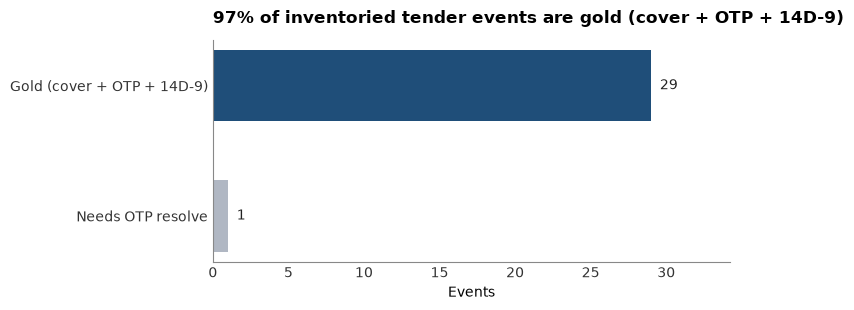

**Claim:** Pipeline throughput in **event** units — almost all inventoried events reach Concise Rep.

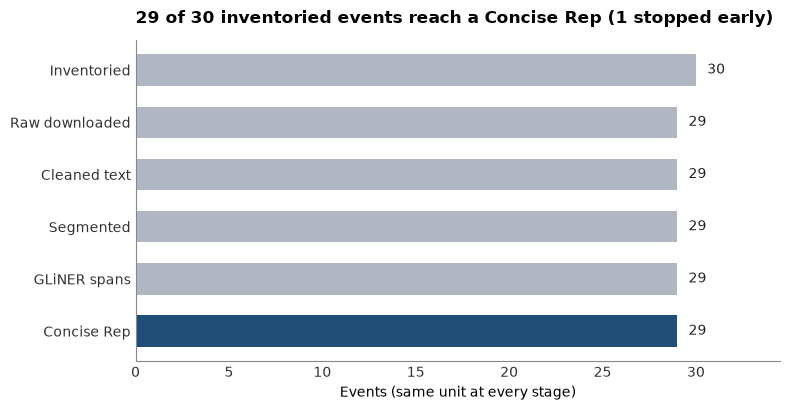

**Claim:** Share of Concise Reps that pass upstream quality gates.

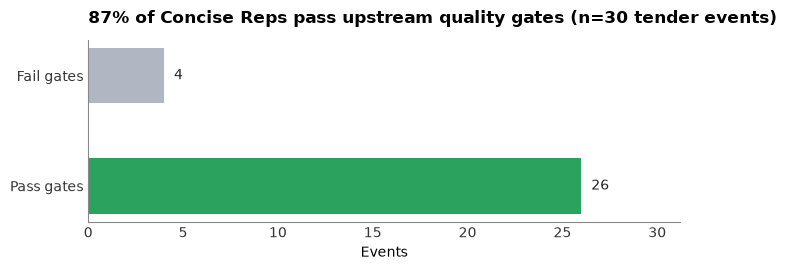

**Claim:** Top-1 price / date / offeror are usually present after ranking.

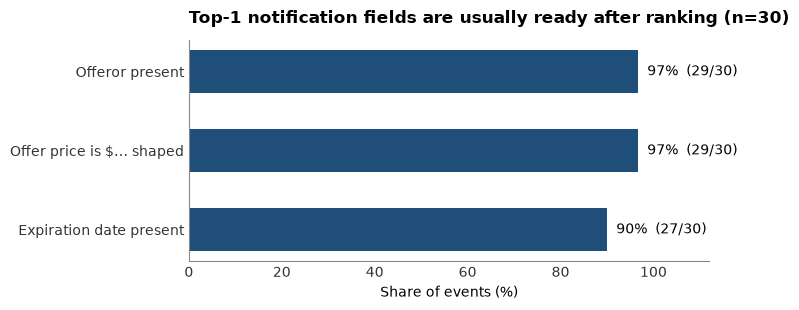

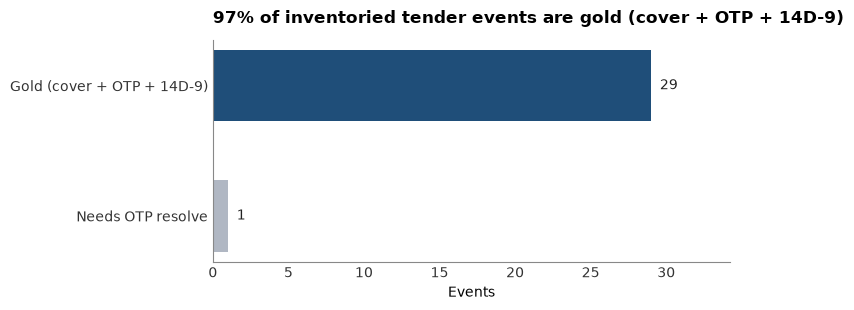

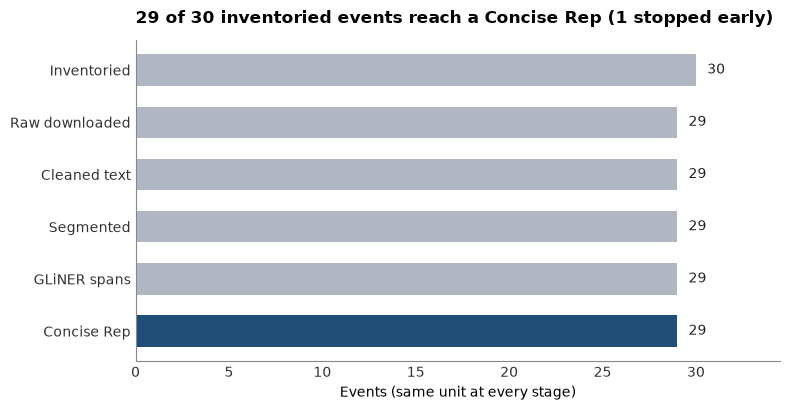

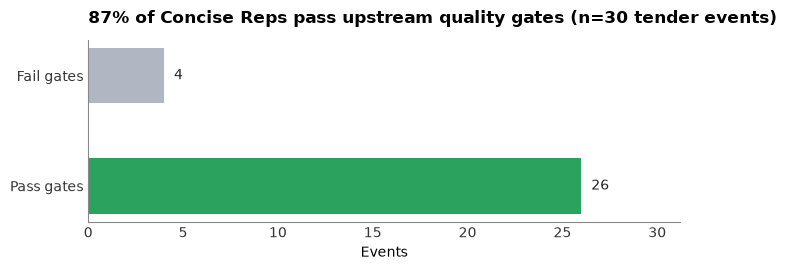

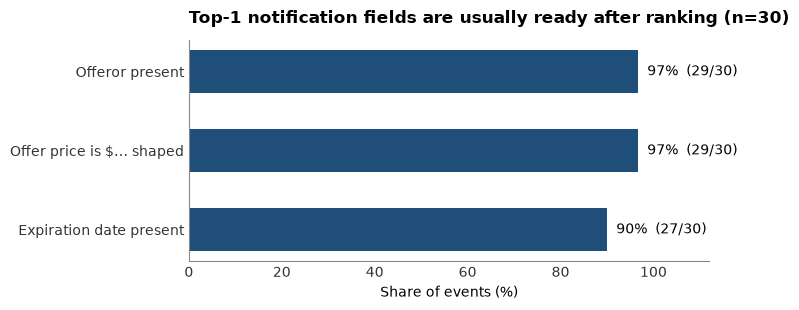

In [3]:
# Story-first figures (one claim each) — see data-visualization-principles
idx = STORE.read_json(STORE.cohort_index_path()) if STORE.cohort_index_path().exists() else {"cohorts": {}}
fig1 = plot_cohort_mix(idx, save=True)
display(Markdown("**Claim:** Nearly all inventoried events meet the gold doc set (cover + OTP + 14D-9)."))
display(fig1)

fig2 = plot_pipeline_funnel(store=STORE, save=True)
display(Markdown("**Claim:** Pipeline throughput in **event** units — almost all inventoried events reach Concise Rep."))
display(fig2)

gate_rows = []
for _, r in cohort.iterrows():
    gate_rows.append({
        "event_id": r["event_id"],
        "ok": bool(r["gate_ok"]),
        "top_offer_price": r.get("top_offer_price"),
        "top_expiration": r.get("top_expiration"),
        "top_offeror": r.get("top_offeror"),
    })
gate_plot_df = pd.DataFrame(gate_rows)
if not gate_plot_df.empty:
    fig3 = plot_quality_gates(gate_plot_df, save=True)
    display(Markdown("**Claim:** Share of Concise Reps that pass upstream quality gates."))
    display(fig3)
    fig4 = plot_top1_field_readiness(gate_plot_df, save=True)
    display(Markdown("**Claim:** Top-1 price / date / offeror are usually present after ranking."))
    display(fig4)


## Demo event

We walk **one gold event** end-to-end so slides can show *raw → cleaned → segmented → spans → Concise Rep*. Prefer an event with Summary Term Sheet / FAQ and a money-shaped top price.


In [4]:
# Prefer FAQ-rich gold with money-shaped top price; fall back to first gated event
demo = cohort[(cohort["n_faq"] > 0) & cohort["top_offer_price"].astype(str).str.contains(r"\$", na=False)]
if demo.empty:
    demo = cohort[cohort["gate_ok"]]
if demo.empty:
    demo = cohort
EVENT_ID = demo.iloc[0]["event_id"]
# Stable presentation default when available
for preferred in ("005-02933", "005-06295", "005-20723"):
    if preferred in set(cohort["event_id"]):
        EVENT_ID = preferred
        break
row = cohort.set_index("event_id").loc[EVENT_ID]
display(Markdown(f"### Demo event: `{EVENT_ID}` — **{row['entity']}**"))
display(pd.DataFrame(row).T[[
    "entity", "cohort", "n_docs", "n_segments", "n_faq", "n_spans",
    "top_offer_price", "top_expiration", "top_offeror", "gate_ok"
]])


### Demo event: `005-02933` — **VOLT INFORMATION SCIENCES, INC.**

,entity,cohort,n_docs,n_segments,n_faq,n_spans,top_offer_price,top_expiration,top_offeror,gate_ok
005-02933,"VOLT INFORMATION SCIENCES, INC.",gold,4,22.0,0,69.0,$6.00,"March 12, 2022","AmericanCyberSystems, Inc.",True


## 1. Inventory — *which* documents matter

**Why:** A tender event can have dozens of filings/exhibits. Notification-critical text lives in a small set:

- **Cover** (SC TO-T/C primary) — parties, CUSIP, security
- **Offer to Purchase (OTP)** — price, deadlines, conditions (FAQ / Summary Term Sheet)
- **Letter of Transmittal (LoT)** — operational tender mechanics
- **SC 14D-9** — target board recommendation / extras

**Input:** EDGAR catalog (`events` / `documents` parquet)  
**Output:** `inventory.json` + cohort tag (`gold` = cover + OTP + 14D-9)


In [5]:
inv = STORE.read_json(STORE.inventory_path(EVENT_ID))
docs_df = pd.DataFrame(inv.get("docs") or [])
display(Markdown("**Cohort / flags**"))
display(pd.Series({
    "event_id": inv.get("event_id"),
    "cohort": inv.get("cohort"),
    "primary_entity": inv.get("primary_entity"),
    "has_cover": inv.get("has_cover"),
    "has_otp": inv.get("has_otp"),
    "has_lot": inv.get("has_lot"),
    "has_14d9": inv.get("has_14d9"),
    "otp_method": inv.get("otp_method"),
    "download_ready": inv.get("download_ready"),
    "n_amendments": inv.get("n_amendments"),
}))
display(Markdown("**Selected docs (roles from EDGAR metadata, not body keyword search)**"))
cols = [c for c in ["role", "form", "file_type", "file_description", "accession", "filename", "file_date"] if c in docs_df.columns]
display(docs_df[cols] if cols else docs_df)


**Cohort / flags**

event_id                                005-02933
cohort                                       gold
primary_entity    VOLT INFORMATION SCIENCES, INC.
has_cover                                    True
has_otp                                      True
has_lot                                      True
has_14d9                                     True
otp_method                              ex99_type
download_ready                               True
n_amendments                                    9
dtype: object

**Selected docs (roles from EDGAR metadata, not body keyword search)**

,role,form,file_type,file_description,accession,filename,file_date
0,cover,SC TO-T,SC TO-T,SC TO-T,0001104659-22-037820,tm229994-1_sctot.htm,2022-03-25 00:00:00
1,otp,SC TO-T,EX-99.(A)(1)(A),EX-99.(A)(1)(A),0001104659-22-037820,tm229994d1_exh-a1a.htm,2022-03-25 00:00:00
2,lot,SC TO-T,EX-99.(A)(1)(B),EX-99.(A)(1)(B),0001104659-22-037820,tm229994d1_exh-a1b.htm,2022-03-25 00:00:00
3,sc_14d9,SC 14D9,SC 14D9,SC 14D9,0001193125-22-085107,d317321dsc14d9.htm,2022-03-25 00:00:00


## 2. Download — raw HTML on disk

**Why:** Citations need immutable bytes (`accession__filename`, sha1). Re-running analysis must not depend on live EDGAR.

**Input:** inventory docs + SEC URLs  
**Output:** `raw/*.htm` + `download_manifest.json`  
**Resume:** existing non-empty raw files are skipped unless `--force`


In [6]:
raw_dir = STORE.raw_dir(EVENT_ID)
raw_files = sorted(raw_dir.glob("*")) if raw_dir.exists() else []
dl = STORE.read_json(STORE.download_manifest_path(EVENT_ID)) if STORE.download_manifest_path(EVENT_ID).exists() else {}
dl_df = pd.DataFrame(dl.get("docs") or [])
display(Markdown(f"**Raw files on disk: {len(raw_files)}**"))
display(pd.DataFrame({"file": [p.name for p in raw_files], "bytes": [p.stat().st_size for p in raw_files]}))
if not dl_df.empty:
    show = [c for c in ["role", "status", "bytes", "sha1", "accession", "filename"] if c in dl_df.columns]
    display(Markdown("**Download manifest (provenance)**"))
    display(dl_df[show])

# Show a short raw HTML snippet (first OTP-like file if possible)
sample = None
for p in raw_files:
    if "ex" in p.name.lower() or "otp" in p.name.lower() or len(raw_files) == 1:
        sample = p
        break
sample = sample or (raw_files[0] if raw_files else None)
if sample:
    text = sample.read_text(encoding="utf-8", errors="replace")
    display(Markdown(f"**Raw snippet** `{sample.name}` (first 800 chars)"))
    print(text[:800])


**Raw files on disk: 4**

,file,bytes
0,0001104659-22-037820__tm229994-1_sctot.htm,92941
1,0001104659-22-037820__tm229994d1_exh-a1a.htm,644995
2,0001104659-22-037820__tm229994d1_exh-a1b.htm,180628
3,0001193125-22-085107__d317321dsc14d9.htm,364627


**Download manifest (provenance)**

,role,status,bytes,sha1,accession,filename
0,cover,skipped,92941,e35658e352be62d2af336c30f1ab46041c9bd54c,0001104659-22-037820,tm229994-1_sctot.htm
1,otp,skipped,644995,f25ccb083511a0831b358b2b55612109ec78c8d5,0001104659-22-037820,tm229994d1_exh-a1a.htm
2,lot,skipped,180628,f27964f87f9b5482efd4e25be70ed7aed3b4fbfe,0001104659-22-037820,tm229994d1_exh-a1b.htm
3,sc_14d9,skipped,364627,59797be019356ce89da3b52c71a35854ed44935d,0001193125-22-085107,d317321dsc14d9.htm


**Raw snippet** `0001104659-22-037820__tm229994d1_exh-a1a.htm` (first 800 chars)

<DOCUMENT>
<TYPE>EX-99.(A)(1)(A)
<SEQUENCE>2
<FILENAME>tm229994d1_exh-a1a.htm
<DESCRIPTION>EX-99.(A)(1)(A)
<TEXT>
<html>
  <head>
    <title>tm229994-1_sctot_DIV_100-exha1a - none - 11.0156226s</title>
  </head>
  <body style="margin-left:auto;margin-right:auto;width:595.31pt;">
    <div style="page-break-after:always; width:595.3pt;margin-left:auto;margin-right:auto;font-style:normal;font-weight:normal;font-variant:normal;text-transform:none;color:#000000;font-family:Times New Roman, Times, serif ;font-size:10pt;">
      <div style="padding:0pt;margin:0pt;font-family:calibri, arial, sans-serif;font-weight:normal;font-style:normal;font-size:8pt;line-height:8pt;">
        <a style="text-decoration:none;color:#003366;" href="#TOC">TABLE OF CONTENTS</a>
      </div>
      <div style="margin-t


## 3. Cleanup — wrappers off, text on

**Why:** EDGAR wraps HTML in `<DOCUMENT>/<TEXT>`. GLiNER and humans need plain text with stable character offsets.

**Input:** `raw/*.htm`  
**Output:** `clean/*.txt` + `*.meta.json` (sha1, word count, role)


In [7]:
clean_dir = STORE.clean_dir(EVENT_ID)
metas = sorted(clean_dir.glob("*.meta.json")) if clean_dir.exists() else []
meta_rows = [STORE.read_json(p) for p in metas]
meta_df = pd.DataFrame(meta_rows)
display(Markdown(f"**Clean docs: {len(metas)}**"))
if not meta_df.empty:
    display(meta_df[[c for c in ["doc_role", "words", "bytes", "sha1", "filename"] if c in meta_df.columns]])

# Show cleaned text snippet for OTP if present
otp_meta = next((m for m in meta_rows if (m.get("doc_role") or "") == "otp"), meta_rows[0] if meta_rows else None)
if otp_meta:
    # reconstruct clean path
    acc, fn = otp_meta.get("accession"), otp_meta.get("filename")
    cpath = STORE.clean_text_path(EVENT_ID, acc, fn)
    clean_txt = cpath.read_text(encoding="utf-8") if cpath.exists() else ""
    display(Markdown(f"**Clean OTP text snippet** (`{cpath.name}`, {len(clean_txt):,} chars)"))
    print(clean_txt[:900])


**Clean docs: 4**

,doc_role,words,bytes,sha1,filename
0,cover,2240,14308,f356e611ca133664257eee58121149cfdac38830,tm229994-1_sctot.htm
1,otp,47361,293779,c25c72761666133cf2941c32d5c35f56d69b3e96,tm229994d1_exh-a1a.htm
2,lot,6565,40810,e3d90b57f9880dfab62c75056295073730c0eaa7,tm229994d1_exh-a1b.htm
3,sc_14d9,27865,177115,8103dd3a22df58dfae9574b2f7c0b1af235f60d8,d317321dsc14d9.htm


**Clean OTP text snippet** (`0001104659-22-037820__tm229994d1_exh-a1a.htm.txt`, 289,239 chars)

tm229994-1_sctot_DIV_100-exha1a - none - 11.0156226s
TABLE OF CONTENTS
Exhibit (a)(1)(A)
​
OFFER TO PURCHASE FOR CASH
All Outstanding Shares of Common Stock
of
VOLT INFORMATION SCIENCES, INC.
at
$6.00 PER SHARE, NET IN CASH
by
VEGA MERGERCO, INC.
(Offeror)
a wholly owned subsidiary of
VEGA CONSULTING, INC.
(Parent)
​
​
THE OFFER AND WITHDRAWAL RIGHTS WILL EXPIRE AT MIDNIGHT, NEW YORK TIME
(I.E., ONE MINUTE AFTER 11:59 P.M., NEW YORK TIME), ON APRIL 21, 2022, UNLESS THE
OFFER IS EXTENDED OR EARLIER TERMINATED.
​
​
Vega MergerCo, Inc., a New York corporation (the “
Offeror
”) and a wholly owned subsidiary of Vega Consulting, Inc., a Delaware corporation (“
Parent
”), is offering to purchase all of the issued and outstanding shares (the “
Shares
”) of common stock, par value $0.10 per share (the “
Common Stock
”), of Volt Information Sciences, Inc., a New York corporation (“
Volt
” or the “


## 4. Segment — put the model where the answer is

**Why:** OTPs are long. GLiNER has a ~384-token window. We **DOM-segment** (TOC anchors, FAQ Q/A, Summary Term Sheet) so price/date live in short, high-value chunks — not buried after truncation.

**Input:** raw HTML + clean text  
**Output:** `segments.json` (`faq`, `priority_section`, `toc_section`, `full_doc`)


In [8]:
seg = STORE.read_json(STORE.segments_path(EVENT_ID))
segs = seg.get("segments") or []
seg_df = pd.DataFrame(segs)
display(Markdown(f"**Segments: {seg.get('n_segments')}** · modes={seg.get('modes')}"))
if not seg_df.empty:
    display(seg_df.groupby(["doc_role", "kind"], dropna=False).size().rename("n").reset_index())
    # show priority / FAQ heads
    focus = seg_df[seg_df["kind"].isin(["priority_section", "faq"])].head(8)
    if focus.empty:
        focus = seg_df.head(8)
    display(Markdown("**High-value segments (heading / question + text preview)**"))
    preview = focus.copy()
    preview["text_preview"] = preview["text"].astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 160)
    cols = [c for c in ["kind", "doc_role", "priority", "heading", "question", "text_preview"] if c in preview.columns]
    display(preview[cols])


**Segments: 22** · modes=['full_doc', 'toc', 'full_doc', 'full_doc']

,doc_role,kind,n
0,cover,full_doc,1
1,lot,full_doc,1
2,otp,priority_section,1
3,otp,toc_section,18
4,sc_14d9,full_doc,1


**High-value segments (heading / question + text preview)**

,kind,doc_role,priority,heading,text_preview
1,priority_section,otp,True,Summary Term Sheet” to this Offer to Pur,Summary Term Sheet” to this Offer to Purchase) to be satisfied upon expiration of the Offer (tak...


## 5. GLiNER — candidate spans (values over headings)

**Why:** We need *extractive* candidates with evidence for the agent. GLiNER zero-shot labels (`offer_price_amount`, `expiration_datetime`, orgs, CUSIP, …).

**Upstream robustness (v2):**
- Sliding windows (~900 chars) so chunks fit the model
- Value-aware **rank_score** (promote `$15.00` / calendar dates; demote `Offer Price` headings)
- Demote depositary / info-agent orgs (Computershare, MacKenzie) for `offeror`
- Always-on narrow **pass-2** on priority/FAQ segments

**Input:** segments  
**Output:** `spans.json` (text, label, score, rank_score, passage, offsets)


In [9]:
spans_payload = STORE.read_json(STORE.spans_path(EVENT_ID))
spans = spans_payload.get("spans") or []
sp_df = pd.DataFrame(spans)
display(Markdown(
    f"**Spans: {spans_payload.get('n_spans')}** · model=`{spans_payload.get('gliner_model')}` · "
    f"pass2={spans_payload.get('pass2')} · status={spans_payload.get('status')}"
))
if not sp_df.empty:
    display(sp_df["field_hint"].value_counts().head(12).to_frame("n"))
    # Top candidates for notification-critical hints
    hints = ["offer_price", "expiration_date", "offeror", "target", "purchaser", "cusip", "ticker", "security_description"]
    tops = []
    for h in hints:
        sub = sp_df[sp_df["field_hint"] == h].sort_values("rank_score", ascending=False).head(1)
        if sub.empty:
            continue
        r = sub.iloc[0]
        tops.append({
            "field_hint": h,
            "raw": r.get("text"),
            "rank_score": round(float(r.get("rank_score") or 0), 3),
            "model_score": round(float(r.get("score") or 0), 3),
            "doc_role": r.get("doc_role"),
            "segment_kind": r.get("segment_kind"),
            "passage_len": len(r.get("passage") or ""),
        })
    display(Markdown("**Top-1 span per key field (after ranking)**"))
    display(pd.DataFrame(tops))

    # Evidence passage for price
    price = sp_df[sp_df["field_hint"] == "offer_price"].sort_values("rank_score", ascending=False)
    if not price.empty:
        p0 = price.iloc[0]
        display(Markdown("**Evidence passage for top offer_price**"))
        print((p0.get("passage") or "")[:700])


**Spans: 69** · model=`urchade/gliner_medium-v2.1` · pass2=True · status=ok

,n
field_hint,
offeror,12
purchaser,12
expiration_date,11
offer_price,10
target,5
ticker,4
security_description,4
effective_date,3
cusip,2


**Top-1 span per key field (after ranking)**

,field_hint,raw,rank_score,model_score,doc_role,segment_kind,passage_len
0,offer_price,$6.00,1.441,0.791,otp,toc_section,456
1,expiration_date,"March 12, 2022",1.645,0.865,otp,priority_section,535
2,offeror,"AmericanCyberSystems, Inc.",1.279,0.879,cover,full_doc,463
3,target,Company,-0.262,0.488,otp,toc_section,487
4,purchaser,"Vega MergerCo, Inc.",1.040,0.740,otp,toc_section,508
5,cusip,928703107,1.638,0.888,cover,full_doc,528
6,ticker,VOLT,1.177,0.827,otp,toc_section,504
7,security_description,Deferred RSU,0.462,0.462,otp,toc_section,661


**Evidence passage for top offer_price**

References to “we,” “us,” or “our,” unless the context otherwise requires, are references to the Offeror.
Securities Sought
All issued and outstanding shares (the “
Shares
”) of common stock, par value $0.10 per share (“
Common Stock
”), of Volt Information Sciences, Inc., a New York corporation (“
Volt
” or the “
Company
”).
Price Offered Per Share
$6.00 per share (the “
Offer Price
”) in cash, net of applicable withholding taxes and without interest.


## 6. Assemble — Concise Representation

**Why:** One event-level JSON the agent can consume: doc inventory + ranked `candidate_facts` + passages. This is the bridge to SEC-only `event_field_values` (see `schema.md`) — **not** the curated BNY notification yet.

**Input:** inventory + spans  
**Output:** `concise/event_rep.json`


In [10]:
rep = STORE.read_json(STORE.event_rep_path(EVENT_ID))
facts = pd.DataFrame(rep.get("candidate_facts") or [])
display(Markdown(
    f"**preprocess_status=`{rep.get('preprocess_status')}`** · cohort=`{rep.get('cohort')}` · "
    f"facts={len(facts)} · exceptions={rep.get('exception_flags')}"
))
display(Markdown("**Doc inventory statuses**"))
display(pd.DataFrame(rep.get("doc_inventory") or []))

if not facts.empty:
    display(Markdown("**Top Concise Rep facts (presentable)**"))
    show = facts.sort_values("rank_score", ascending=False).head(12).copy()
    show["passage_preview"] = show["passage"].astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 120)
    display(show[[c for c in [
        "field_hint", "raw", "rank_score", "confidence", "method", "doc_role", "faq_question", "passage_preview"
    ] if c in show.columns]])

gate = check_event_rep(rep)
display(Markdown(f"**Quality gate for this event: {'PASS' if gate['ok'] else 'FAIL'}**"))
display(pd.Series(gate["checks"]))
if gate["failures"]:
    display(Markdown(f"Failures: `{gate['failures']}`"))


**preprocess_status=`ok`** · cohort=`gold` · facts=69 · exceptions=['14d9_download_missing_or_failed']

**Doc inventory statuses**

,role,status,sha1,hit_id,accession,filename
0,cover,skipped,e35658e352be62d2af336c30f1ab46041c9bd54c,0001104659-22-037820:tm229994-1_sctot.htm,0001104659-22-037820,tm229994-1_sctot.htm
1,otp,skipped,f25ccb083511a0831b358b2b55612109ec78c8d5,0001104659-22-037820:tm229994d1_exh-a1a.htm,0001104659-22-037820,tm229994d1_exh-a1a.htm
2,lot,skipped,f27964f87f9b5482efd4e25be70ed7aed3b4fbfe,0001104659-22-037820:tm229994d1_exh-a1b.htm,0001104659-22-037820,tm229994d1_exh-a1b.htm
3,sc_14d9,skipped,59797be019356ce89da3b52c71a35854ed44935d,0001193125-22-085107:d317321dsc14d9.htm,0001193125-22-085107,d317321dsc14d9.htm


**Top Concise Rep facts (presentable)**

,field_hint,raw,rank_score,confidence,method,doc_role,faq_question,passage_preview
0,expiration_date,"March 12, 2022",1.644843,0.864843,gliner,otp,None,The Offeror is a New York corporation that was formed for the sole purpose of making the Offer a...
1,cusip,928703107,1.638048,0.888048,gliner,cover,None,(Name of Filing Persons (Parent)) Rajiv Sardana (Name of Filing Persons (Affiliate of Parent and...
2,expiration_date,"March 25, 2022",1.630034,0.850034,gliner,otp,None,"The Information Agent for the Offer is: ​ ​ Georgeson LLC 1290 Avenue of the Americas, 9 th Floo..."
3,offer_price,$6.00,1.440545,0.790545,gliner,otp,None,"References to “we,” “us,” or “our,” unless the context otherwise requires, are references to the..."
4,offer_price,$1.7 billion,1.421498,0.771498,gliner,otp,None,"Headquartered in Atlanta, Georgia, ACS has over $1.7 billion in annual revenue with more than 20..."
5,expiration_date,"April 4, 2022",1.393201,0.743201,gliner,otp,None,The Offeror and Volt filed a Notification and Report Form under the HSR Act with the FTC and the...
6,offer_price,$5.96,1.338267,0.688267,gliner,otp,None,"On March 24, 2022, the last full trading day prior to the commencement of the Offer, the reporte..."
7,expiration_date,"April 21, 2022",1.302050,0.652050,gliner,otp,None,"Scheduled Expiration Date Midnight, New York time (i.e., one minute after 11:59 p.m., New York t..."
8,offer_price,$7.75 million,1.290649,0.640649,gliner,otp,None,"In connection with the sale, Mr. Grubbs received approximately $7.75 million on account of certa..."
9,offeror,"AmericanCyberSystems, Inc.",1.278612,0.878612,gliner,cover,None,"​ ​ (d)(3) ​ ​ Confidentiality Agreement, dated as of December 30, 2021, by and between Volt and..."


**Quality gate for this event: PASS**

top1_offer_price                                  $6.00
top1_expiration_date                     March 12, 2022
top1_offeror                 AmericanCyberSystems, Inc.
top1_security_description                  Deferred RSU
passage_len_median                                  487
dtype: object

## 7. Cohort findings — what to say on the slide

These numbers are computed live from artifacts on disk (re-run after more `--pending-only` batches).


In [11]:
reps = {}
for eid in EVENT_IDS:
    p = STORE.event_rep_path(eid)
    if p.exists():
        reps[eid] = STORE.read_json(p)
gates = check_gold_artifacts(reps)
gate_rows = []
for eid, g in gates["events"].items():
    gate_rows.append({"event_id": eid, "ok": g["ok"], "failures": ", ".join(g["failures"]), **g["checks"]})
gate_df = pd.DataFrame(gate_rows)

n = len(gate_df)
summary = pd.Series({
    "events_with_rep": n,
    "gates_pass": int(gate_df["ok"].sum()) if n else 0,
    "gates_pass_pct": round(100 * gate_df["ok"].mean(), 1) if n else 0,
    "top1_price_has_$": int(gate_df["top1_offer_price"].astype(str).str.contains(r"\$", na=False).sum()) if n else 0,
    "median_passage_len": int(gate_df["passage_len_median"].median()) if n else 0,
    "total_candidate_facts": int(cohort["n_facts"].sum()),
})
display(Markdown("### Presentable summary metrics"))
display(summary)

fail = gate_df[~gate_df["ok"]]
if not fail.empty:
    display(Markdown("### Remaining gate failures (honest residual)"))
    display(fail[["event_id", "failures", "top1_offer_price", "top1_expiration_date", "top1_offeror"]])

display(Markdown("""
**Talking points**
1. We selected **priority SEC docs only** (not the whole exhibit zoo).
2. Segmentation puts GLiNER on **Summary Term Sheet / FAQ**, where price & dates live.
3. Ranking demotes headings and agent banks so top-1 **offer_price / expiration / offeror** are usually notification-usable.
4. Concise Rep is **evidence-bearing candidates** for the agent — not a final BNY email (accounts, CUSIP lists from internal systems stay out of scope).
5. Pipeline is **resumable**: `--pending-only` skips finished events and continues the gold cohort.
"""))


### Presentable summary metrics

events_with_rep            29.0
gates_pass                 26.0
gates_pass_pct             89.7
top1_price_has_$           29.0
median_passage_len        435.0
total_candidate_facts    2175.0
dtype: float64

### Remaining gate failures (honest residual)

,event_id,failures,top1_offer_price,top1_expiration_date,top1_offeror
5,005-12857,top1_expiration_date_not_calendar,"$70,000,000.00",NaN,"Ancora Advisors, LLC"
21,005-41257,top1_expiration_date_not_calendar,$220 million,NaN,Iconix Acquisition LLC
27,005-45332,passage_median_lt_300,Ch$140,"January 17, 2021",Citibank N.A.



**Talking points**
1. We selected **priority SEC docs only** (not the whole exhibit zoo).
2. Segmentation puts GLiNER on **Summary Term Sheet / FAQ**, where price & dates live.
3. Ranking demotes headings and agent banks so top-1 **offer_price / expiration / offeror** are usually notification-usable.
4. Concise Rep is **evidence-bearing candidates** for the agent — not a final BNY email (accounts, CUSIP lists from internal systems stay out of scope).
5. Pipeline is **resumable**: `--pending-only` skips finished events and continues the gold cohort.


## 8. Pipeline metrics & funnel charts


Metrics CSV: `/Users/kedarvaidya/Desktop/BNY-Capstone-Project/outputs/to_preprocess_metrics.csv`

,path,stage,status,written_at,n_reps_ok,n_reps_failed,n_candidate_facts,n_entities,pct_method_gliner,n_events_pending,...,n_incomplete,otp_method_mix,coverage_csv,n_reps_upserted,n_facts_inserted,n_entities_inserted,n_events_segmented,n_otp_toc_docs,n_otp_faq_only_docs,n_fallback_full_doc
0,tender,assemble,ok,2026-09-17T07:36:16.845655+00:00,27.0,0.0,2005.0,2005.0,100.0,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,tender,cleanup,ok,2026-09-17T07:22:45.894338+00:00,NaN,NaN,NaN,NaN,NaN,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,tender,download,ok,2026-09-17T07:22:43.408661+00:00,NaN,NaN,NaN,NaN,NaN,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tender,gliner,ok,2026-09-17T07:36:16.696003+00:00,NaN,NaN,NaN,NaN,NaN,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tender,inventory,ok,2026-09-17T06:12:57.678203+00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,"{""ex99_type"": 2}",outputs/to_source_coverage.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,tender,load_db,ok,2026-09-17T06:33:04.061626+00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.0,525.0,525.0,NaN,NaN,NaN,NaN
6,tender,segment,ok,2026-09-17T07:22:47.454452+00:00,NaN,NaN,NaN,NaN,NaN,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,27.0,21.0,0.0,80.0


### Presentation figures (active titles, direct labels, one claim each)

**preprocess_cohort_mix.png**

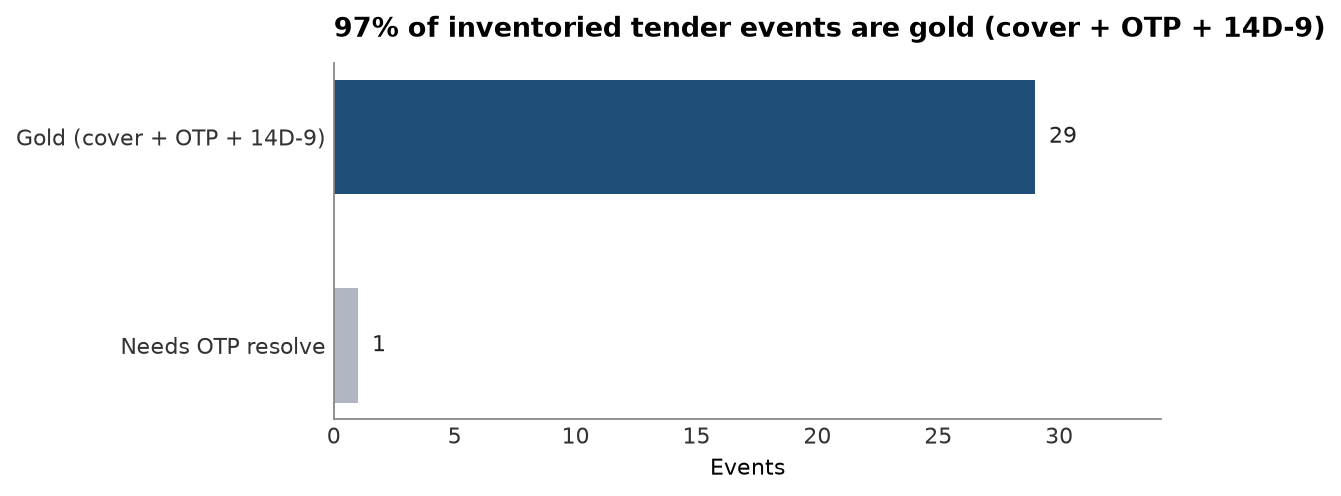

**preprocess_selection_funnel.png**

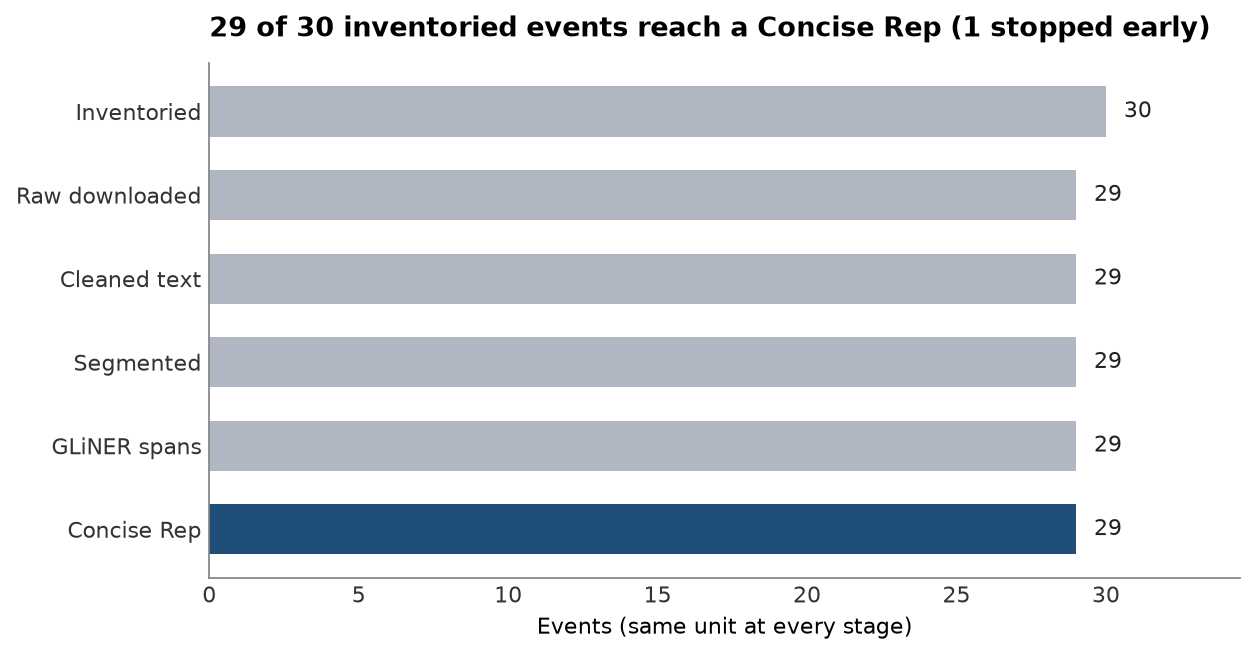

**preprocess_quality_gates.png**

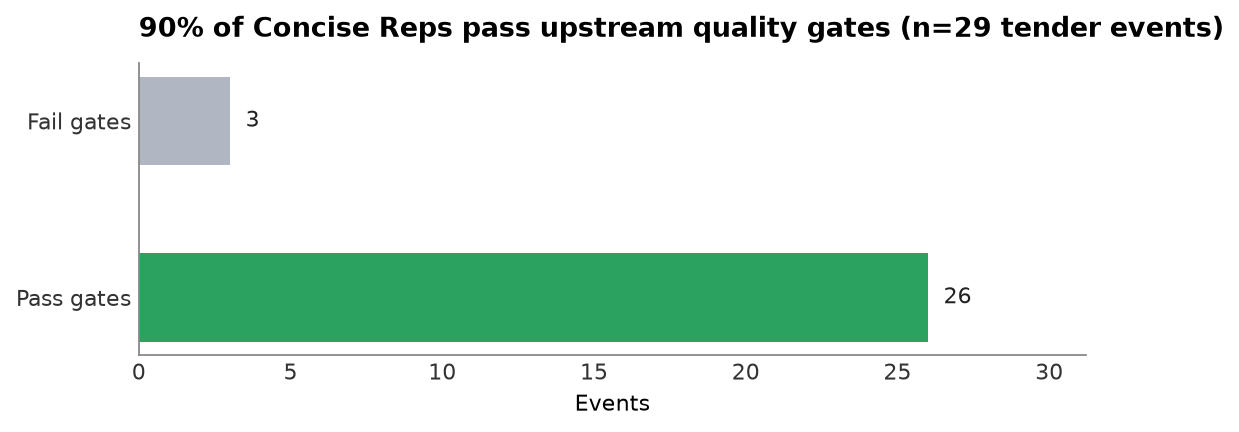

**preprocess_top1_field_readiness.png**

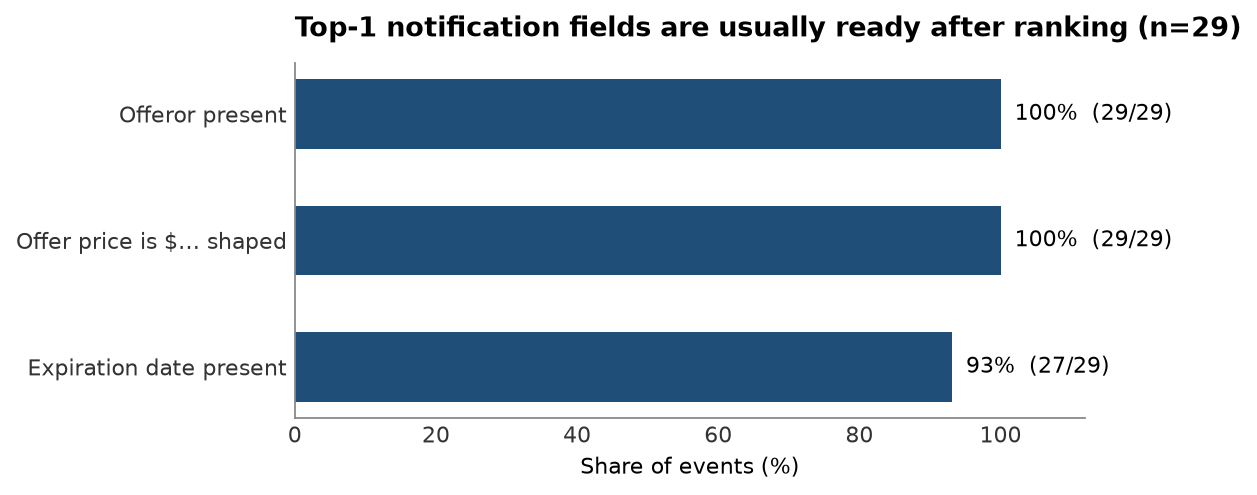

viz figures: ['preprocess_cohort_mix.png', 'preprocess_selection_funnel.png', 'preprocess_quality_gates.png', 'preprocess_top1_field_readiness.png']


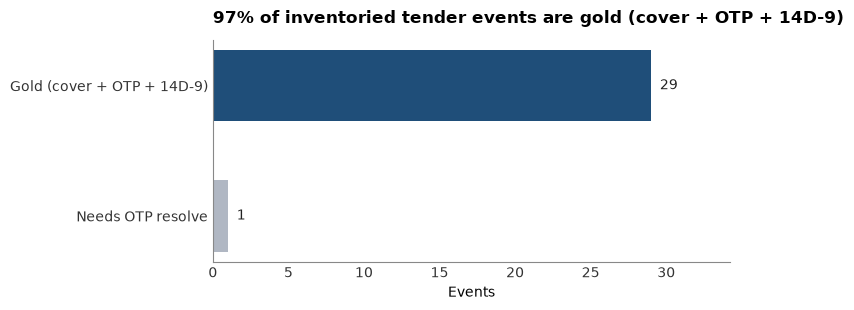

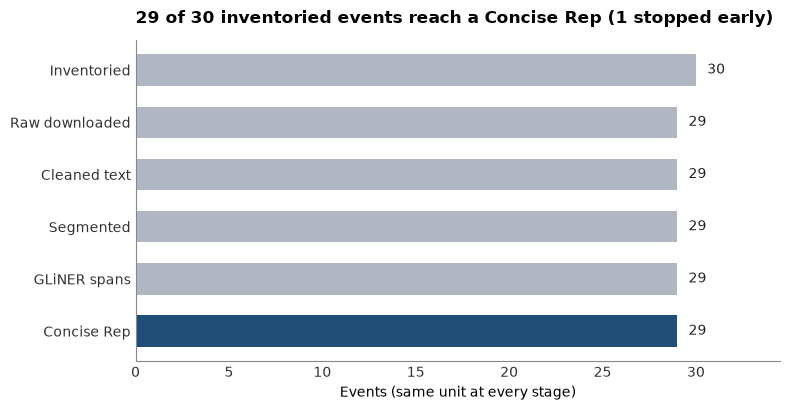

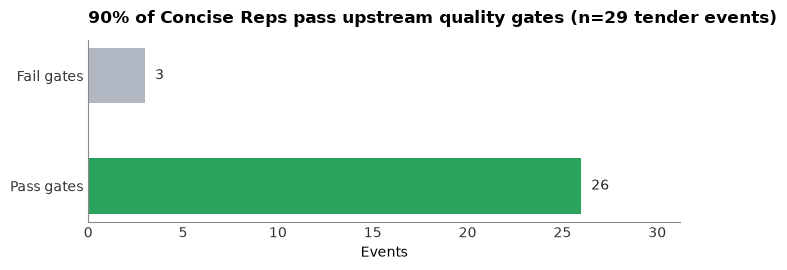

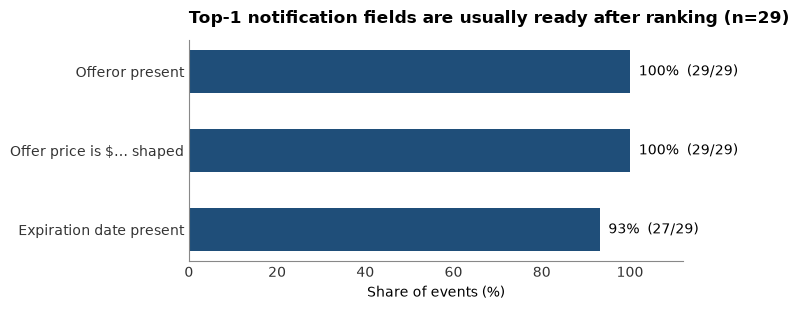

In [12]:
metrics_path = write_metrics_csv(PATH_NAME, DEFAULT_PREPROCESS_ROOT)
metrics_df = collect_stage_metrics(PATH_NAME, DEFAULT_PREPROCESS_ROOT)
display(Markdown(f"Metrics CSV: `{metrics_path}`"))
display(metrics_df.head(12) if not metrics_df.empty else metrics_df)

# Regenerate + show principle-aligned PNGs
viz_out = run_viz(path_name=PATH_NAME, event_ids=[EVENT_ID], inspect_limit=1, show_progress=False)
fig_dir = ROOT / "figures" / "preprocess"
display(Markdown("### Presentation figures (active titles, direct labels, one claim each)"))
for name in [
    "preprocess_cohort_mix.png",
    "preprocess_selection_funnel.png",
    "preprocess_quality_gates.png",
    "preprocess_top1_field_readiness.png",
]:
    p = fig_dir / name
    if p.exists():
        display(Markdown(f"**{name}**"))
        display(Image(filename=str(p)))
print("viz figures:", viz_out.get("figures"))


## 9. What is *not* claimed yet

- F1 vs human-annotated notification fields  
- BNY-internal fields (accounts, withholdings, ops status)  
- Final curated `event_field_values` (agent stage still to build)  
- Non-tender paths (exchange / rights / merger / conversion) beyond stubs  

**Next demo step:** agent that reads Concise Rep → writes SEC-only notification fields with citations.
